## Regularization in NN.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import L1, L2

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
X, y = make_moons(
    n_samples=2000,
    noise=0.25,
    random_state=42
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 2)
y shape: (2000,)


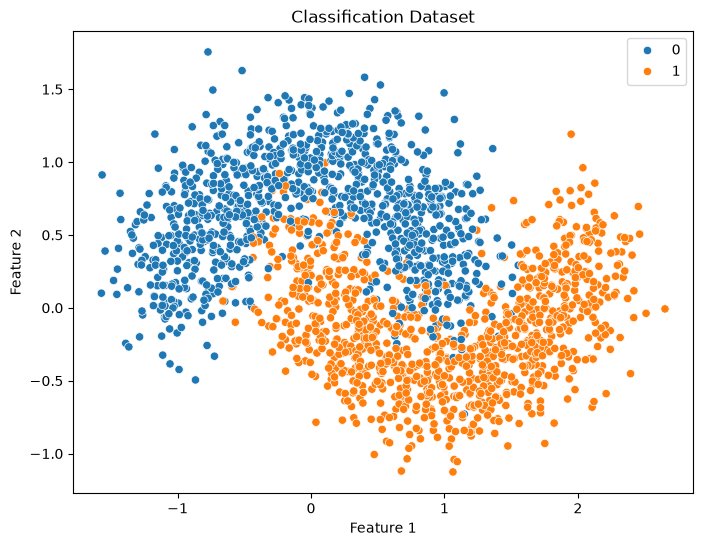

In [4]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=y
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Classification Dataset")

plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (1600, 2)
Testing : (400, 2)


In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### No Regularization

In [7]:
model_none = Sequential([
    Dense(128, activation="relu", input_shape=(2,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

c:\Users\alili\100_days_Deep_Learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model_none.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history_none = model_none.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [10]:
loss_none, accuracy_none = model_none.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", loss_none)
print("Test Accuracy:", accuracy_none)

Test Loss: 0.21320533752441406
Test Accuracy: 0.925000011920929


### L1 Regularization

In [11]:
kernel_regularizer=L1(0.001)

In [12]:
model_l1 = Sequential([
    Dense(
        128,
        activation="relu",
        kernel_regularizer=L1(0.001),
        input_shape=(2,)
    ),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=L1(0.001)
    ),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=L1(0.001)
    ),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=L1(0.001)
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

In [13]:
model_l1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history_l1 = model_l1.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [15]:
loss_l1, accuracy_l1 = model_l1.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("L1 Test Loss:", loss_l1)
print("L1 Test Accuracy:", accuracy_l1)

L1 Test Loss: 0.21460099518299103
L1 Test Accuracy: 0.925000011920929


### L2 Regularization

In [16]:
kernel_regularizer=L2(0.001)

In [17]:
model_l2 = Sequential([
    Dense(
        128,
        activation="relu",
        kernel_regularizer=L2(0.001),
        input_shape=(2,)
    ),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=L2(0.001)
    ),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=L2(0.001)
    ),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=L2(0.001)
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

In [18]:
model_l2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [19]:
history_l2 = model_l2.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [20]:
loss_l2, accuracy_l2 = model_l2.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("L2 Test Loss:", loss_l2)
print("L2 Test Accuracy:", accuracy_l2)

L2 Test Loss: 0.18911872804164886
L2 Test Accuracy: 0.925000011920929


In [21]:
results = pd.DataFrame({
    "Model": [
        "No Regularization",
        "L1",
        "L2"
    ],

    "Test Loss": [
        loss_none,
        loss_l1,
        loss_l2
    ],

    "Test Accuracy": [
        accuracy_none,
        accuracy_l1,
        accuracy_l2
    ]
})

results

,Model,Test Loss,Test Accuracy
0,No Regularization,0.213205,0.925
1,L1,0.214601,0.925
2,L2,0.189119,0.925


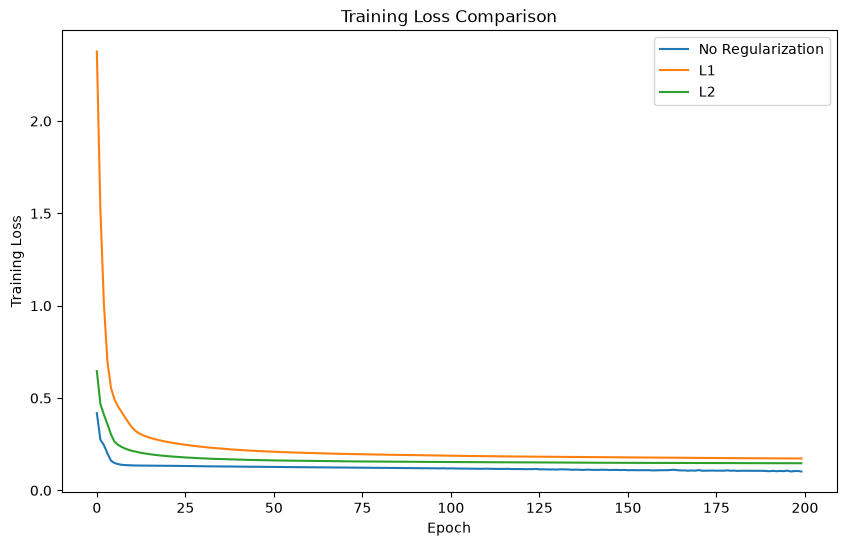

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_none.history["loss"],
    label="No Regularization"
)

plt.plot(
    history_l1.history["loss"],
    label="L1"
)

plt.plot(
    history_l2.history["loss"],
    label="L2"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")

plt.legend()
plt.show()

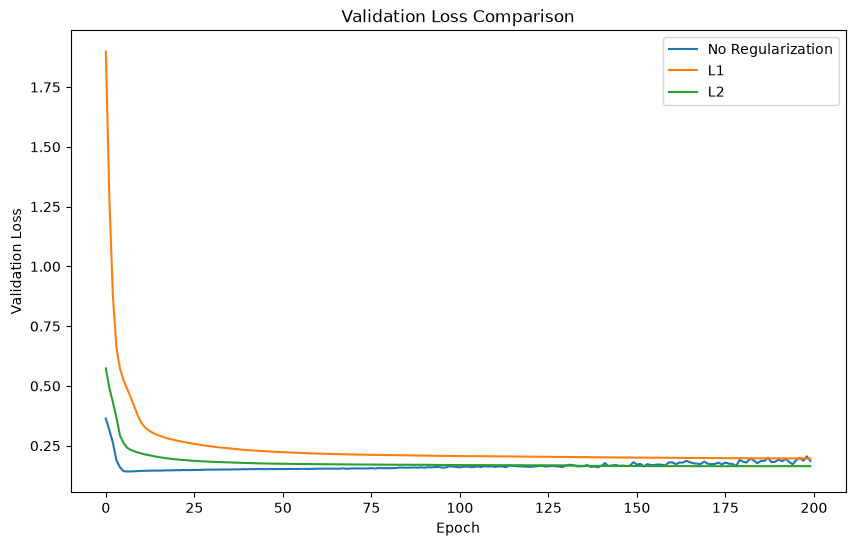

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_none.history["val_loss"],
    label="No Regularization"
)

plt.plot(
    history_l1.history["val_loss"],
    label="L1"
)

plt.plot(
    history_l2.history["val_loss"],
    label="L2"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")

plt.legend()
plt.show()

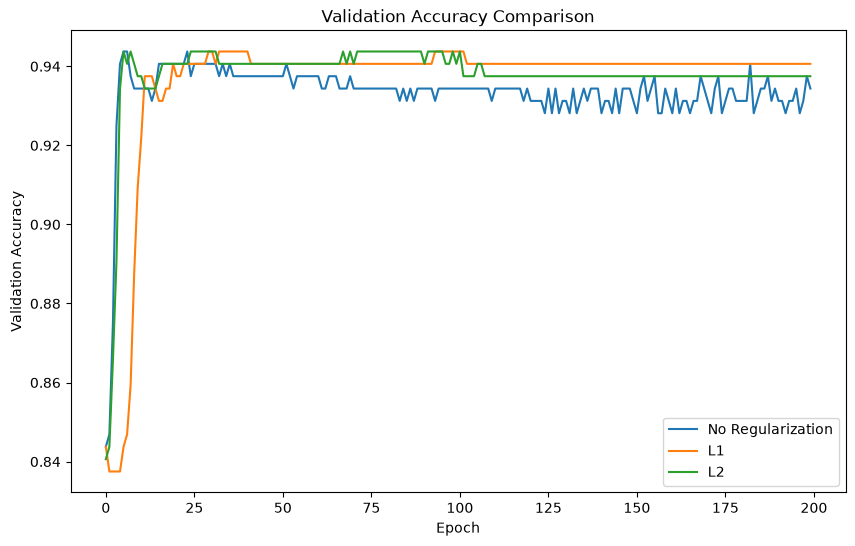

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_none.history["val_accuracy"],
    label="No Regularization"
)

plt.plot(
    history_l1.history["val_accuracy"],
    label="L1"
)

plt.plot(
    history_l2.history["val_accuracy"],
    label="L2"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")

plt.legend()
plt.show()

In [25]:
weights_none = model_none.layers[0].get_weights()[0]
weights_l1 = model_l1.layers[0].get_weights()[0]
weights_l2 = model_l2.layers[0].get_weights()[0]

print("No Regularization:")
print(weights_none[:5])

print("\nL1:")
print(weights_l1[:5])

print("\nL2:")
print(weights_l2[:5])

No Regularization:
[[-1.72598492e-02  1.64038152e-01 -2.68385023e-01  2.16522574e-01
  -6.53637499e-02 -1.57400534e-01  2.70719498e-01 -6.76250607e-02
   2.32372895e-01  5.32797053e-02  2.24740192e-01  1.83339894e-01
   2.37377756e-03  1.97605908e-01  2.48193592e-01  6.63675889e-02
   2.54440993e-01  2.79856287e-02 -2.68877953e-01  1.38548780e-02
   2.71446984e-02 -7.97637179e-03  2.62887925e-01 -9.59428102e-02
  -1.83503255e-02  2.89094508e-01  1.57072037e-01 -2.09318861e-01
   1.21970467e-01 -1.80384710e-01 -5.06774858e-02 -1.85601220e-01
   1.00300543e-01 -2.02375919e-01  1.84010103e-01 -1.42859057e-01
   7.22101778e-02 -6.97449669e-02 -1.51204348e-01 -1.70831785e-01
   3.66752073e-02  1.90956190e-01 -4.38220538e-02  2.63160825e-01
  -3.68940756e-02  1.86606959e-01  1.68499380e-01  1.31494090e-01
   1.29274145e-01  2.00986177e-01 -5.41979680e-03 -8.07183310e-02
   2.52656013e-01  2.37353787e-01  3.22062731e-01  1.15766518e-01
  -1.76201791e-01 -1.07360497e-01 -2.45417967e-01 -1.1816

In [26]:
threshold = 1e-3

zero_none = np.sum(
    np.abs(weights_none) < threshold
)

zero_l1 = np.sum(
    np.abs(weights_l1) < threshold
)

zero_l2 = np.sum(
    np.abs(weights_l2) < threshold
)

total_weights = weights_none.size

print("Near-zero weights:")

print(
    "No Regularization:",
    zero_none,
    "/",
    total_weights
)

print(
    "L1:",
    zero_l1,
    "/",
    total_weights
)

print(
    "L2:",
    zero_l2,
    "/",
    total_weights
)

Near-zero weights:
No Regularization: 1 / 256
L1: 215 / 256
L2: 49 / 256


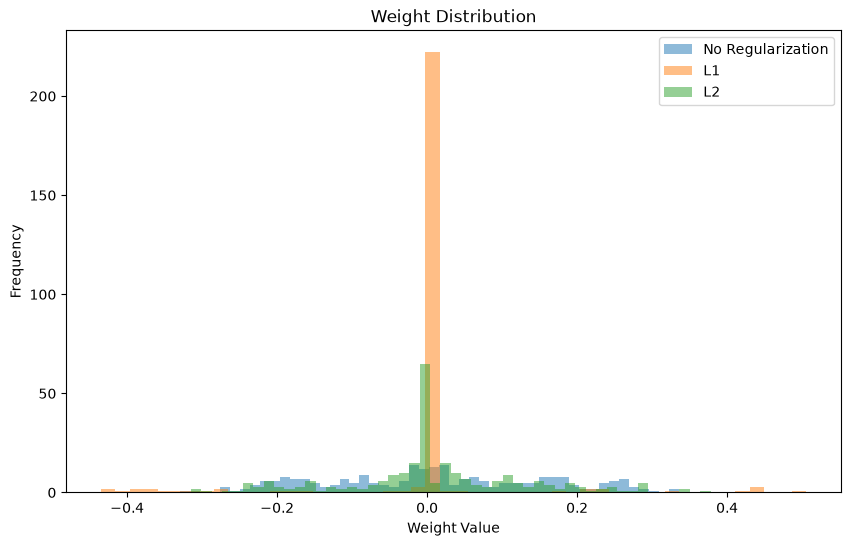

In [27]:
plt.figure(figsize=(10, 6))

plt.hist(
    weights_none.flatten(),
    bins=50,
    alpha=0.5,
    label="No Regularization"
)

plt.hist(
    weights_l1.flatten(),
    bins=50,
    alpha=0.5,
    label="L1"
)

plt.hist(
    weights_l2.flatten(),
    bins=50,
    alpha=0.5,
    label="L2"
)

plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.title("Weight Distribution")

plt.legend()
plt.show()

In [28]:
y_pred_none = (
    model_none.predict(
        X_test,
        verbose=0
    ) > 0.5
).astype(int).ravel()

y_pred_l1 = (
    model_l1.predict(
        X_test,
        verbose=0
    ) > 0.5
).astype(int).ravel()

y_pred_l2 = (
    model_l2.predict(
        X_test,
        verbose=0
    ) > 0.5
).astype(int).ravel()

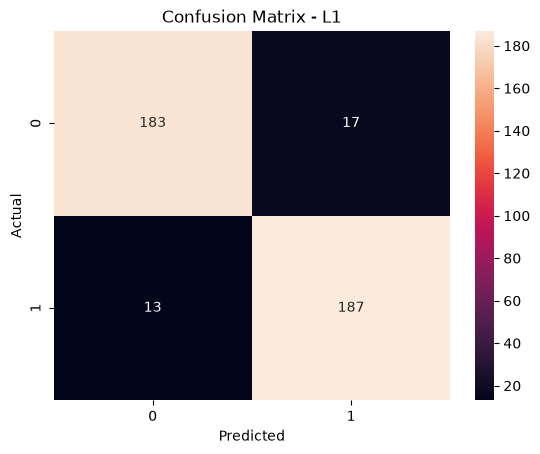

In [29]:
cm_l1 = confusion_matrix(
    y_test,
    y_pred_l1
)

sns.heatmap(
    cm_l1,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - L1")

plt.show()